In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.__version__

'3.0.2'

In [3]:
pd.show_versions()


INSTALLED VERSIONS
------------------
commit                : ab90747e3dae0e69b1bdbf083820b8075689b34b
python                : 3.12.10
python-bits           : 64
OS                    : Windows
OS-release            : 11
Version               : 10.0.26200
machine               : AMD64
processor             : Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
byteorder             : little
LC_ALL                : None
LANG                  : None
LOCALE                : English_United States.1252

pandas                : 3.0.2
numpy                 : 2.4.4
dateutil              : 2.9.0.post0
pip                   : 26.1.1
Cython                : None
sphinx                : None
IPython               : 9.13.0
adbc-driver-postgresql: None
adbc-driver-sqlite    : None
bs4                   : 4.14.3
bottleneck            : None
fastparquet           : None
fsspec                : None
html5lib              : None
hypothesis            : None
gcsfs                 : None
jinja2          

In [4]:
data = {'animal': ['cat', 'cat', 'snake', 'dog', 'dog', 'cat', 'snake', 'cat', 'dog', 'dog'],
        'age' : [2.5, 3, 0.5, np.nan, 5, 2, 4.5, np.nan, 7, 3],
        'priority': ['yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no']}
label = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']

In [5]:
df = pd.DataFrame(data, index= label)

In [6]:
df

,animal,age,priority
a,cat,2.5,yes
b,cat,3.0,yes
c,snake,0.5,no
d,dog,NaN,yes
e,dog,5.0,no
f,cat,2.0,no
g,snake,4.5,no
h,cat,NaN,yes
i,dog,7.0,no
j,dog,3.0,no


In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 10 entries, a to j
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   animal    10 non-null     str    
 1   age       8 non-null      float64
 2   priority  10 non-null     str    
dtypes: float64(1), str(2)
memory usage: 320.0+ bytes


In [8]:
df.shape


(10, 3)

In [9]:
df.head(3)

,animal,age,priority
a,cat,2.5,yes
b,cat,3.0,yes
c,snake,0.5,no


In [10]:
df[['animal', 'age']]

,animal,age
a,cat,2.5
b,cat,3.0
c,snake,0.5
d,dog,NaN
e,dog,5.0
f,cat,2.0
g,snake,4.5
h,cat,NaN
i,dog,7.0
j,dog,3.0


In [11]:
df.iloc[[2,3,7], [0,1]]

,animal,age
c,snake,0.5
d,dog,NaN
h,cat,NaN


In [12]:
df[['animal', 'age']].iloc[[3,4,8]]

,animal,age
d,dog,NaN
e,dog,5.0
i,dog,7.0


In [13]:
df['visit'] = [1,3,2,3,2,3,1,1,2,1]

In [14]:
df

,animal,age,priority,visit
a,cat,2.5,yes,1
b,cat,3.0,yes,3
c,snake,0.5,no,2
d,dog,NaN,yes,3
e,dog,5.0,no,2
f,cat,2.0,no,3
g,snake,4.5,no,1
h,cat,NaN,yes,1
i,dog,7.0,no,2
j,dog,3.0,no,1


In [15]:
filt_visit = (df['visit'] > 3)
df.loc[filt_visit]

,animal,age,priority,visit


In [16]:
df['age'].isna()


a    False
b    False
c    False
d     True
e    False
f    False
g    False
h     True
i    False
j    False
Name: age, dtype: bool

In [17]:
df[df['age'].isna()]

,animal,age,priority,visit
d,dog,NaN,yes,3
h,cat,NaN,yes,1


In [18]:
cat_filt = (df['animal'] == 'cat') & (df['age'] < 3) 
df.loc[cat_filt]

,animal,age,priority,visit
a,cat,2.5,yes,1
f,cat,2.0,no,3


In [19]:
age_filt = (df['age'] >= 2)  & (df['age'] <= 4)
df.loc[age_filt]

,animal,age,priority,visit
a,cat,2.5,yes,1
b,cat,3.0,yes,3
f,cat,2.0,no,3
j,dog,3.0,no,1


In [20]:
df.tail()

,animal,age,priority,visit
f,cat,2.0,no,3
g,snake,4.5,no,1
h,cat,NaN,yes,1
i,dog,7.0,no,2
j,dog,3.0,no,1


In [21]:
df.loc['f','age'] = 1.5

In [22]:
df.loc['f','age']

np.float64(1.5)

In [23]:
df.tail()

,animal,age,priority,visit
f,cat,1.5,no,3
g,snake,4.5,no,1
h,cat,NaN,yes,1
i,dog,7.0,no,2
j,dog,3.0,no,1


In [24]:
df['visit'].sum()

np.int64(19)

In [25]:
df.sum()

animal      catcatsnakedogdogcatsnakecatdogdog
age                                       27.0
priority              yesyesnoyesnononoyesnono
visit                                       19
dtype: object

In [26]:
animal_grp = df.groupby('animal')

In [27]:
average_age = animal_grp['age'].mean()

In [28]:
average_age.reset_index()

,animal,age
0,cat,2.333333
1,dog,5.000000
2,snake,2.500000


In [29]:
new_df= pd.DataFrame([{'animal' : 'lion', 'age': 4, 'priority': 'yes', 'visit': 3}])
df = pd.concat([df, new_df], ignore_index= True)

In [30]:
df

,animal,age,priority,visit
0,cat,2.5,yes,1
1,cat,3.0,yes,3
2,snake,0.5,no,2
3,dog,NaN,yes,3
4,dog,5.0,no,2
5,cat,1.5,no,3
6,snake,4.5,no,1
7,cat,NaN,yes,1
8,dog,7.0,no,2
9,dog,3.0,no,1


In [31]:
df.drop(index = 10, inplace=True)

In [32]:
df['animal'].value_counts()

animal
cat      4
dog      4
snake    2
Name: count, dtype: int64

In [33]:
animal_grp.value_counts() 

animal  age  priority  visit
cat     2.5  yes       1        1
        3.0  yes       3        1
        1.5  no        3        1
dog     5.0  no        2        1
        7.0  no        2        1
        3.0  no        1        1
snake   0.5  no        2        1
        4.5  no        1        1
Name: count, dtype: int64

In [34]:
df.sort_values(by= ['age', 'visit'], ascending= [False, True])

,animal,age,priority,visit
8,dog,7.0,no,2
4,dog,5.0,no,2
6,snake,4.5,no,1
9,dog,3.0,no,1
1,cat,3.0,yes,3
0,cat,2.5,yes,1
5,cat,1.5,no,3
2,snake,0.5,no,2
7,cat,NaN,yes,1
3,dog,NaN,yes,3


In [35]:
df['priority']= 'yes', 'yes', 'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no'

In [36]:
df

,animal,age,priority,visit
0,cat,2.5,yes,1
1,cat,3.0,yes,3
2,snake,0.5,no,2
3,dog,NaN,yes,3
4,dog,5.0,no,2
5,cat,1.5,no,3
6,snake,4.5,no,1
7,cat,NaN,yes,1
8,dog,7.0,no,2
9,dog,3.0,no,1


In [37]:
df['priority'] = df['priority'].replace({'yes': 'True', 'no': 'False'})

In [38]:
df

,animal,age,priority,visit
0,cat,2.5,True,1
1,cat,3.0,True,3
2,snake,0.5,False,2
3,dog,NaN,True,3
4,dog,5.0,False,2
5,cat,1.5,False,3
6,snake,4.5,False,1
7,cat,NaN,True,1
8,dog,7.0,False,2
9,dog,3.0,False,1


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   animal    10 non-null     str    
 1   age       8 non-null      float64
 2   priority  10 non-null     str    
 3   visit     10 non-null     int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 452.0 bytes


In [40]:
df

,animal,age,priority,visit
0,cat,2.5,True,1
1,cat,3.0,True,3
2,snake,0.5,False,2
3,dog,NaN,True,3
4,dog,5.0,False,2
5,cat,1.5,False,3
6,snake,4.5,False,1
7,cat,NaN,True,1
8,dog,7.0,False,2
9,dog,3.0,False,1


In [41]:
df['animal'] = df['animal'].replace({'snake': 'python'})

In [42]:
df

,animal,age,priority,visit
0,cat,2.5,True,1
1,cat,3.0,True,3
2,python,0.5,False,2
3,dog,NaN,True,3
4,dog,5.0,False,2
5,cat,1.5,False,3
6,python,4.5,False,1
7,cat,NaN,True,1
8,dog,7.0,False,2
9,dog,3.0,False,1


In [43]:
df.pivot_table(values= 'age', index= 'animal', columns= 'visit', aggfunc= 'mean')

visit,1,2,3
animal,,,
cat,2.5,NaN,2.25
dog,3.0,6.0,NaN
python,4.5,0.5,NaN


In [44]:
df_int = pd.DataFrame({'A':[1,2,2,3,4,5,5,5,6,7,7]})
df_int

,A
0,1
1,2
2,2
3,3
4,4
5,5
6,5
7,5
8,6
9,7


In [45]:
df_int.loc[df_int['A'].shift() != df_int['A']]

,A
0,1
1,2
3,3
4,4
5,5
8,6
9,7


In [46]:
df_num = pd.DataFrame(np.random.random(size=(5,10)), columns = list('abcdesghij'))

In [47]:
df_num.sum().idxmin()

'c'

In [48]:
df_num1 = pd.DataFrame(np.random.random(size=(5,3)))
df_num1

,0,1,2
0,0.406657,0.727514,0.091771
1,0.462098,0.304588,0.865441
2,0.961599,0.350531,0.539549
3,0.965476,0.828846,0.811588
4,0.105639,0.899976,0.204777


In [49]:
df_num1.mean(axis=1)

0    0.408647
1    0.544043
2    0.617227
3    0.868637
4    0.403464
dtype: float64

In [50]:
df_row_ave = df_num1.sub(df_num1.mean(axis=1), axis=0)

In [51]:
df_row_ave

,0,1,2
0,-0.001990,0.318867,-0.316876
1,-0.081944,-0.239455,0.321399
2,0.344373,-0.266696,-0.077677
3,0.096840,-0.039791,-0.057049
4,-0.297825,0.496512,-0.198687


In [52]:
df_num1 = df_num1 - df_num1.mean(axis=1)
df_num1

,0,1,2,3,4
0,-0.001990,0.183471,-0.525456,NaN,NaN
1,0.053451,-0.239455,0.248215,NaN,NaN
2,0.552952,-0.193511,-0.077677,NaN,NaN
3,0.556829,0.284803,0.194361,NaN,NaN
4,-0.303008,0.355934,-0.412449,NaN,NaN


In [53]:
df_num1.mean()

0    0.171647
1    0.078248
2   -0.114601
3         NaN
4         NaN
dtype: float64

In [54]:
df_num = pd.DataFrame(np.random.random(size=(5,10)), columns = list('abcdesghij'))
df_num.sum().sort_values().index[0]

'b'

In [55]:
df1 = pd.DataFrame(np.random.randint(0,2, size=(10,3)))
df1

,0,1,2
0,0,0,1
1,0,1,0
2,1,0,1
3,0,1,1
4,1,0,1
5,1,1,1
6,0,0,0
7,0,1,1
8,1,0,0
9,1,1,1


In [56]:
len(df1.drop_duplicates())

7

In [57]:
df1_row = df1.drop_duplicates().value_counts().sum()
float(df1_row)

7.0

In [58]:
nan= np.nan
data= [[0.04, nan, nan, 0.2, nan, 0.43, 0.71, 0.1, nan, nan],
       [nan, nan, nan, 0.4, 0.76, nan, nan, 0.67, 0.76, 0.16],
       [nan, nan, 0.5, nan, 0.31, 0.4, nan, nan, 0.24, 0.01],
       [0.49, nan, nan, 0.62, 0.73, 0.26, 0.85, nan, nan, nan],
       [nan, nan, 0.41, nan, 0.05, nan, 0.61,  nan, 0.48, 0.68]]

columns =list('abcdefghij')
df2 = pd.DataFrame(data, columns = columns)

In [59]:
((df2.isna().cumsum(axis=1)) == 3).idxmax(axis=1)

0    e
1    c
2    d
3    h
4    d
dtype: str

In [60]:
df3 = pd.DataFrame({'grp': list('aaabbcaabcccbcc'),
                   'vals': [12, 345, 3, 1, 45, 14, 4, 52, 54, 23, 235, 21, 57, 3, 87]})
df3

,grp,vals
0,a,12
1,a,345
2,a,3
3,b,1
4,b,45
5,c,14
6,a,4
7,a,52
8,b,54
9,c,23


In [61]:
df3_grp = df3.groupby('grp')

In [62]:
df3 = df3_grp.apply(lambda x: x.sort_values('vals', ascending=False))

In [63]:
df3_grp['vals'].apply(lambda x : x.nlargest(3).sum())

grp
a    409
b    156
c    345
Name: vals, dtype: int64

In [64]:
df3_grp['vals'].max()

grp
a    345
b     57
c    235
Name: vals, dtype: int64

In [65]:
df4 = pd.DataFrame(np.random.RandomState(8765).randint(1,101, size = (100, 2)), columns = ['A', 'B'])
df4.sort_values(by =['A','B']).head(2)

,A,B
40,1,40
47,1,83


In [66]:
df4.groupby(pd.cut(df4['A'], np.arange(0,101,10)))['B'].agg(['mean', 'sum'])

,mean,sum
A,,
"(0, 10]",57.727273,635
"(10, 20]",45.000000,360
"(20, 30]",52.500000,315
"(30, 40]",51.000000,306
"(40, 50]",57.692308,750
"(50, 60]",47.333333,284
"(60, 70]",47.111111,424
"(70, 80]",43.833333,526
"(80, 90]",64.230769,835


In [67]:
df4.groupby(pd.cut(df4['A'], np.arange(0,101,10)))['B'].agg(['mean', 'sum'])

,mean,sum
A,,
"(0, 10]",57.727273,635
"(10, 20]",45.000000,360
"(20, 30]",52.500000,315
"(30, 40]",51.000000,306
"(40, 50]",57.692308,750
"(50, 60]",47.333333,284
"(60, 70]",47.111111,424
"(70, 80]",43.833333,526
"(80, 90]",64.230769,835


In [68]:
df5 = pd.DataFrame({'X': [7,2,0,3,4,2,5,0,3,4]})

In [69]:
df5

,X
0,7
1,2
2,0
3,3
4,4
5,2
6,5
7,0
8,3
9,4


In [70]:
x = (df5['X'] != 0).cumsum()
y= x != x.shift()
df5['Y'] = y.groupby((y!= y.shift()).cumsum()).cumsum()

In [71]:
df5

,X,Y
0,7,1
1,2,2
2,0,0
3,3,1
4,4,2
5,2,3
6,5,4
7,0,0
8,3,1
9,4,2


In [72]:
df6 = pd.DataFrame(np.random.RandomState(30).randint(1, 101, size= (8,8)))

In [73]:
ldf6 = df6.unstack().nlargest(3).sort_values().index
list(ldf6)

[(5, 7), (6, 4), (2, 5)]

In [74]:
df7 = pd.DataFrame({"vals": np.random.RandomState(31).randint(-30,30, size = 15), "grps": np.random.RandomState(31).choice(["A","B"], size = 15)})

In [75]:
df7

,vals,grps
0,-12,A
1,-7,B
2,-14,A
3,4,A
4,-7,A
5,28,B
6,-2,A
7,-1,A
8,8,A
9,-2,B


In [76]:
means = df7[df7['vals'] > 0 ].groupby('grps').mean()
a_means = means.loc['A']['vals']
b_means = means.loc['B']['vals']

df7['patched_vals'] = np.where(df7['grps'] == 'A', a_means, b_means)
df7['patched_vals'] = np.where(df7['vals'] < 0, df7['patched_vals'], df7['vals'])

In [77]:
df7

,vals,grps,patched_vals
0,-12,A,13.6
1,-7,B,28.0
2,-14,A,13.6
3,4,A,4.0
4,-7,A,13.6
5,28,B,28.0
6,-2,A,13.6
7,-1,A,13.6
8,8,A,8.0
9,-2,B,28.0


In [78]:
df8 = pd.DataFrame({'group': list('aabbabbbabab'), 'values': [1, 2, 3, np.nan, 2, 3, np.nan, 1, 7, 3, np.nan, 8]})
df8 

,group,values
0,a,1.0
1,a,2.0
2,b,3.0
3,b,NaN
4,a,2.0
5,b,3.0
6,b,NaN
7,b,1.0
8,a,7.0
9,b,3.0


In [79]:
g1 = df8.groupby('group')['values']
g2 = df8.fillna(0).groupby('group')['values']

rolling_mean = g2.rolling(3, min_periods = 1).sum() / g1.rolling(3, min_periods = 1).count()
rolling_mean = rolling_mean.reset_index(level=0, drop=True)

In [80]:
rolling_mean.sort_index()

0     1.000000
1     1.500000
2     3.000000
3     3.000000
4     1.666667
5     3.000000
6     3.000000
7     2.000000
8     3.666667
9     2.000000
10    4.500000
11    4.000000
Name: values, dtype: float64

In [81]:
dt_index = pd.date_range('2015-01-01' , '2015-12-31',freq= 'D')
df9 = pd.Series(np.random.randint(201, size = len(dt_index)), index = dt_index)

In [82]:
df9

2015-01-01    158
2015-01-02    100
2015-01-03     93
2015-01-04    160
2015-01-05     53
             ... 
2015-12-27     42
2015-12-28     72
2015-12-29    166
2015-12-30     24
2015-12-31    195
Freq: D, Length: 365, dtype: int32

In [83]:
dt_index = pd.date_range('2015-01-01' , '2015-12-31',freq= 'D')
df10 = pd.DataFrame(np.random.randint(201, size = len(dt_index)), columns = ['numbers'], index = dt_index)
df10['DayofWeek'] = df10.index.day_name()

In [84]:
df10 

,numbers,DayofWeek
2015-01-01,173,Thursday
2015-01-02,149,Friday
2015-01-03,20,Saturday
2015-01-04,197,Sunday
2015-01-05,197,Monday
...,...,...
2015-12-27,137,Sunday
2015-12-28,192,Monday
2015-12-29,107,Tuesday
2015-12-30,24,Wednesday


In [85]:
wed_filt = (df10['DayofWeek'] == 'Wednesday')
df10.loc[wed_filt]['numbers'].agg(['mean', 'median', 'sum'])

mean        98.730769
median      95.000000
sum       5134.000000
Name: numbers, dtype: float64

In [86]:
df10.resample('ME')['numbers'].mean()

2015-01-31    103.225806
2015-02-28     83.321429
2015-03-31    100.032258
2015-04-30     99.800000
2015-05-31    113.645161
2015-06-30    100.166667
2015-07-31    103.258065
2015-08-31     96.000000
2015-09-30     84.466667
2015-10-31    122.000000
2015-11-30     94.800000
2015-12-31     99.096774
Freq: ME, Name: numbers, dtype: float64

In [87]:
df10.resample('4ME')['numbers'].idxmax()

2015-01-31   2015-01-18
2015-05-31   2015-05-19
2015-09-30   2015-07-17
2016-01-31   2015-10-16
Freq: 4ME, Name: numbers, dtype: datetime64[us]

In [88]:
df11 = pd.date_range('2015-01-01' , '2016-12-31', freq='WOM-3THU')
df11

DatetimeIndex(['2015-01-15', '2015-02-19', '2015-03-19', '2015-04-16',
               '2015-05-21', '2015-06-18', '2015-07-16', '2015-08-20',
               '2015-09-17', '2015-10-15', '2015-11-19', '2015-12-17',
               '2016-01-21', '2016-02-18', '2016-03-17', '2016-04-21',
               '2016-05-19', '2016-06-16', '2016-07-21', '2016-08-18',
               '2016-09-15', '2016-10-20', '2016-11-17', '2016-12-15'],
              dtype='datetime64[us]', freq='WOM-3THU')

In [89]:
df12 = df11.to_frame(name='Third_Thursdays')
df12.reset_index()

,index,Third_Thursdays
0,2015-01-15,2015-01-15
1,2015-02-19,2015-02-19
2,2015-03-19,2015-03-19
3,2015-04-16,2015-04-16
4,2015-05-21,2015-05-21
5,2015-06-18,2015-06-18
6,2015-07-16,2015-07-16
7,2015-08-20,2015-08-20
8,2015-09-17,2015-09-17
9,2015-10-15,2015-10-15


In [90]:
df12.columns

Index(['Third_Thursdays'], dtype='str')

In [91]:
df13 = pd.DataFrame({'From_To' : ['LoNDon_Paris', 'Madrid_miLan', 'lonDon_stockholm', 'Budapest_Paris', 'Brussel_London'],
                     'Flight_number': [10045, np.nan, 10065, np.nan, 10085],
                     'Recent_Delays': [[23,47], [], [24, 43, 87], [13], [67, 32]],
                     'Airline': ['KLM(!)', '<Air France(12)>', '(Bristish Airways. )', '12. Air France', '"Swiss Air"']})
df13

,From_To,Flight_number,Recent_Delays,Airline
0,LoNDon_Paris,10045.0,"[23, 47]",KLM(!)
1,Madrid_miLan,NaN,[],<Air France(12)>
2,lonDon_stockholm,10065.0,"[24, 43, 87]",(Bristish Airways. )
3,Budapest_Paris,NaN,[13],12. Air France
4,Brussel_London,10085.0,"[67, 32]","""Swiss Air"""


In [92]:
df13['Flight_number'] = np.arange(10045, 10086, 10)
df13

,From_To,Flight_number,Recent_Delays,Airline
0,LoNDon_Paris,10045,"[23, 47]",KLM(!)
1,Madrid_miLan,10055,[],<Air France(12)>
2,lonDon_stockholm,10065,"[24, 43, 87]",(Bristish Airways. )
3,Budapest_Paris,10075,[13],12. Air France
4,Brussel_London,10085,"[67, 32]","""Swiss Air"""


In [93]:
temp = df13.copy()
temp[['From', 'To']] = temp['From_To'].str.split('_', expand=True)
temp

,From_To,Flight_number,Recent_Delays,Airline,From,To
0,LoNDon_Paris,10045,"[23, 47]",KLM(!),LoNDon,Paris
1,Madrid_miLan,10055,[],<Air France(12)>,Madrid,miLan
2,lonDon_stockholm,10065,"[24, 43, 87]",(Bristish Airways. ),lonDon,stockholm
3,Budapest_Paris,10075,[13],12. Air France,Budapest,Paris
4,Brussel_London,10085,"[67, 32]","""Swiss Air""",Brussel,London


In [94]:
temp[['From', 'To']] = temp[['From', 'To']].map(lambda x: x.title())
temp

,From_To,Flight_number,Recent_Delays,Airline,From,To
0,LoNDon_Paris,10045,"[23, 47]",KLM(!),London,Paris
1,Madrid_miLan,10055,[],<Air France(12)>,Madrid,Milan
2,lonDon_stockholm,10065,"[24, 43, 87]",(Bristish Airways. ),London,Stockholm
3,Budapest_Paris,10075,[13],12. Air France,Budapest,Paris
4,Brussel_London,10085,"[67, 32]","""Swiss Air""",Brussel,London


In [95]:
cols_to_use = temp.columns.difference(df13.columns)
df13 = pd.merge(df13, temp[cols_to_use], how='left', right_index= True, left_index=True)
df13.drop(columns='From_To', inplace=True)
df13

,Flight_number,Recent_Delays,Airline,From,To
0,10045,"[23, 47]",KLM(!),London,Paris
1,10055,[],<Air France(12)>,Madrid,Milan
2,10065,"[24, 43, 87]",(Bristish Airways. ),London,Stockholm
3,10075,[13],12. Air France,Budapest,Paris
4,10085,"[67, 32]","""Swiss Air""",Brussel,London


In [96]:
df13['Airline'] = df13['Airline'].str.replace(r'[^A-Za-z ]', '', regex=True).str.strip()
df13

,Flight_number,Recent_Delays,Airline,From,To
0,10045,"[23, 47]",KLM,London,Paris
1,10055,[],Air France,Madrid,Milan
2,10065,"[24, 43, 87]",Bristish Airways,London,Stockholm
3,10075,[13],Air France,Budapest,Paris
4,10085,"[67, 32]",Swiss Air,Brussel,London


In [97]:
df13[['delay_1', 'delay_2', 'delay_3']] = df13['Recent_Delays'].apply(pd.Series)
df13.drop(columns = 'Recent_Delays', inplace = True)
df13

,Flight_number,Airline,From,To,delay_1,delay_2,delay_3
0,10045,KLM,London,Paris,23.0,47.0,NaN
1,10055,Air France,Madrid,Milan,NaN,NaN,NaN
2,10065,Bristish Airways,London,Stockholm,24.0,43.0,87.0
3,10075,Air France,Budapest,Paris,13.0,NaN,NaN
4,10085,Swiss Air,Brussel,London,67.0,32.0,NaN


In [98]:
#delays = df13['Recent_Delays'].apply(pd.Series)
#delays.columns = ['delay_{}'.format(n) for n in range(1, len(delay.columns)+1)]  ..another approach

In [99]:
letters = ['A', 'B', 'C']
numbers = list(range(10))
index = pd.MultiIndex.from_product([letters, numbers], names =['letters', 'numbers'])
df14 = pd.Series(np.random.randint(150, size = len(index)), index = index)
df14

letters  numbers
A        0           86
         1          139
         2           56
         3          127
         4            8
         5          138
         6           72
         7          101
         8            8
         9           35
B        0          117
         1           38
         2           93
         3           66
         4           52
         5            7
         6           21
         7          129
         8          148
         9          123
C        0           89
         1          106
         2           86
         3           31
         4          142
         5           26
         6           15
         7          145
         8           99
         9           77
dtype: int32

In [100]:
df14.index.is_monotonic_increasing

True

In [101]:
df14.loc[:, [1,3,6]]

letters  numbers
A        1          139
         3          127
         6           72
B        1           38
         3           66
         6           21
C        1          106
         3           31
         6           15
dtype: int32

In [102]:
df14.loc[pd.IndexSlice[:'B', 5:]]

letters  numbers
A        5          138
         6           72
         7          101
         8            8
         9           35
B        5            7
         6           21
         7          129
         8          148
         9          123
dtype: int32

In [103]:
df14.loc[:'B', 5:]

letters  numbers
A        5          138
         6           72
         7          101
         8            8
         9           35
B        5            7
         6           21
         7          129
         8          148
         9          123
dtype: int32

In [104]:
df14.groupby(level=0).sum()

letters
A    770
B    794
C    816
dtype: int32

In [105]:
df14.unstack().sum(axis= 1)

letters
A    770
B    794
C    816
dtype: int64

In [106]:
df15 = df14.swaplevel(0,1)
df15

numbers  letters
0        A           86
1        A          139
2        A           56
3        A          127
4        A            8
5        A          138
6        A           72
7        A          101
8        A            8
9        A           35
0        B          117
1        B           38
2        B           93
3        B           66
4        B           52
5        B            7
6        B           21
7        B          129
8        B          148
9        B          123
0        C           89
1        C          106
2        C           86
3        C           31
4        C          142
5        C           26
6        C           15
7        C          145
8        C           99
9        C           77
dtype: int32

In [107]:
df15.index.is_monotonic_increasing

False

In [108]:
if not df15.index.is_monotonic_increasing:
    df15 = df15.sort_index()

df15

numbers  letters
0        A           86
         B          117
         C           89
1        A          139
         B           38
         C          106
2        A           56
         B           93
         C           86
3        A          127
         B           66
         C           31
4        A            8
         B           52
         C          142
5        A          138
         B            7
         C           26
6        A           72
         B           21
         C           15
7        A          101
         B          129
         C          145
8        A            8
         B          148
         C           99
9        A           35
         B          123
         C           77
dtype: int32

In [109]:
ghotemin = np.arange(1,11)
gbusiness = np.arange(1,11)
hotemin = pd.DataFrame({'HOTEMIN POST': ghotemin, 'BUSINESS': gbusiness})
hotemin

,HOTEMIN POST,BUSINESS
0,1,1
1,2,2
2,3,3
3,4,4
4,5,5
5,6,6
6,7,7
7,8,8
8,9,9
9,10,10


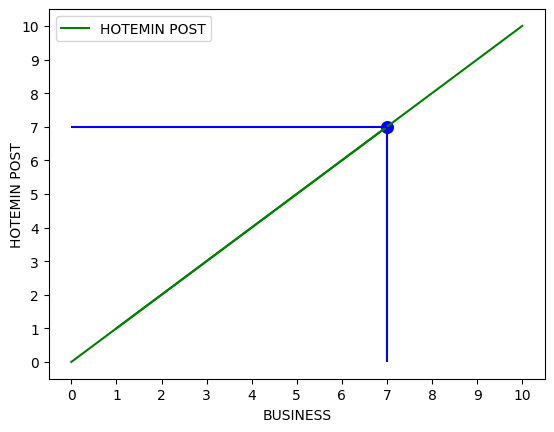

In [110]:
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt
%matplotlib inline

ax = hotemin.plot(x = 'BUSINESS', y = 'HOTEMIN POST', color = 'green')
ax.set_ylabel('HOTEMIN POST')
ax.yaxis.set_label_coords(-0.05, 0.5)
ax.plot([0, 7], [0, 7], color ='green')

ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))

ax.vlines(x = 7, ymin = 0, ymax= 7, color = 'blue')
ax.hlines(y = 7, xmin = 0, xmax = 7, color = 'blue')

ax.scatter(7,7, color = 'blue', s= 70)

plt.show()